In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

In [2]:
cifar_dir = './cifar10_curv_scores'

In [3]:
def load_scores_for_dir(dir_path, num_runs=5):
    score_dict = dict()
    for i in range(num_runs):
        run_dict = np.load(f'{dir_path}/run_{i+1}.npz')
        scores = run_dict['scores']
        scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
        score_dict[i+1] = scores
    return pd.DataFrame(score_dict)

def load_subset_scores_for_dir(dir_path, num_runs=5):
    total_dict = dict()
    for i in range(num_runs):
        run_dict = np.load(f'{dir_path}/run_{i+1}.npz')
        subset, scores = run_dict['subset'], run_dict['scores']
        scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
        total_dict[f'idxs {i+1}'] = subset
        total_dict[f'scores {i+1}'] = scores[subset]
    return pd.DataFrame(total_dict)

def load_non_subset_scores_for_dir(dir_path, num_runs=5):
    total_dict = dict()
    for i in range(num_runs):
        run_dict = np.load(f'{dir_path}/run_{i+1}.npz')
        subset, scores = run_dict['subset'], run_dict['scores']
        scores = (scores - np.min(scores)) / (np.max(scores) - np.min(scores))
        mask = np.ones(len(scores), bool)
        mask[subset] = 0
        total_dict[f'scores {i+1}'] = scores[mask]
    return pd.DataFrame(total_dict)

In [4]:
def get_averages_from_run(dir_path, num_runs=5):
    score_dict = load_scores_for_dir(dir_path, num_runs=num_runs)
    return np.array([np.mean(score_dict[i+1]) for i in range(num_runs)])

def get_averages_from_subsets(dir_path, num_runs=5):
    subset_df = load_subset_scores_for_dir(dir_path, num_runs=num_runs)
    return np.array([np.mean(subset_df[f'scores {i+1}']) for i in range(num_runs)])

def get_non_attack_averages(dir_path, num_runs=5):
    score_dict = load_non_subset_scores_for_dir(dir_path, num_runs=num_runs)
    return np.array([np.mean(score_dict[f'scores {i+1}']) for i in range(num_runs)])

In [5]:
SIZES = [10, 100, 1000]

def get_error_bar_line_from_prefix(prefix, num_runs=5):
    sizes = np.array(SIZES)
    moms = np.array([np.mean(get_averages_from_subsets(f'{prefix}_{size}', num_runs=num_runs)) for size in SIZES])
    stdoms = np.array([np.std(get_averages_from_subsets(f'{prefix}_{size}', num_runs=num_runs)) for size in SIZES])
    return np.vstack([sizes, moms, stdoms])

def get_non_bar_line_from_prefix(prefix, num_runs=5):
    sizes = np.array(SIZES)
    moms = np.array([np.mean(get_non_attack_averages(f'{prefix}_{size}', num_runs=num_runs)) for size in SIZES])
    stdoms = np.array([np.std(get_non_attack_averages(f'{prefix}_{size}', num_runs=num_runs)) for size in SIZES])
    return np.vstack([sizes, moms, stdoms])


In [6]:
def plot_prefix(prefix, fmt, label, color):
    x = get_error_bar_line_from_prefix(prefix)
    plt.errorbar(x[0], x[1], x[2], fmt=fmt, label=label, color=color)

def plot_non(prefix, fmt, label, color):
    x = get_non_bar_line_from_prefix(prefix)
    plt.errorbar(x[0], x[1], x[2], fmt=fmt, label=label, color=color)

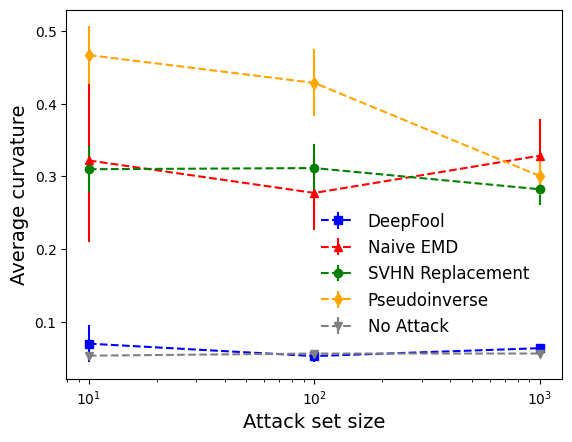

In [7]:
plot_prefix(f'{cifar_dir}/deepfool02_vgg', fmt='s--', label='DeepFool', color='blue')
plot_prefix(f'{cifar_dir}/naiveemd_vgg', fmt='^--', label='Naive EMD', color='red')
plot_prefix(f'{cifar_dir}/svhn_vgg', fmt='o--', label='SVHN Replacement', color='green')
plot_prefix(f'{cifar_dir}/pinv_vgg', fmt='d--', label='Pseudoinverse', color='orange')
plot_non(f'{cifar_dir}/pinv_vgg', fmt='v--', label='No Attack', color='grey')
plt.xscale('log')
plt.ylabel('Average curvature', fontsize=14)
plt.xlabel('Attack set size', fontsize=14)
plt.legend(loc=(0.5, 0.1), frameon=False, fontsize=12)
plt.show()

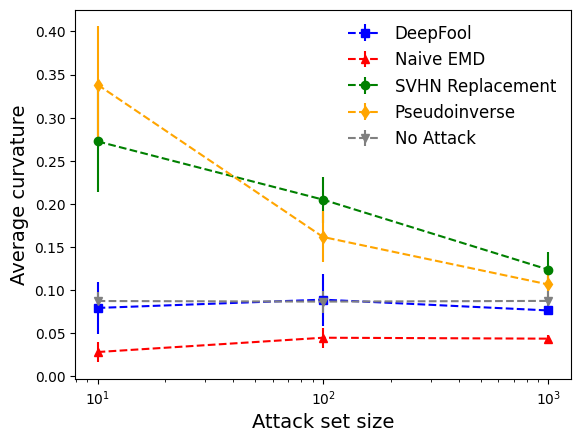

In [8]:
plot_prefix(f'{cifar_dir}/deepfool02_resnet', fmt='s--', label='DeepFool', color='blue')
plot_prefix(f'{cifar_dir}/naiveemd_resnet', fmt='^--', label='Naive EMD', color='red')
plot_prefix(f'{cifar_dir}/svhn_resnet', fmt='o--', label='SVHN Replacement', color='green')
plot_prefix(f'{cifar_dir}/pinv_resnet', fmt='d--', label='Pseudoinverse', color='orange')
plot_non(f'{cifar_dir}/pinv_resnet', fmt='v--', label='No Attack', color='grey')
plt.xscale('log')
plt.ylabel('Average curvature', fontsize=14)
plt.xlabel('Attack set size', fontsize=14)
plt.legend(loc='upper right', frameon=False, fontsize=12)
plt.show()

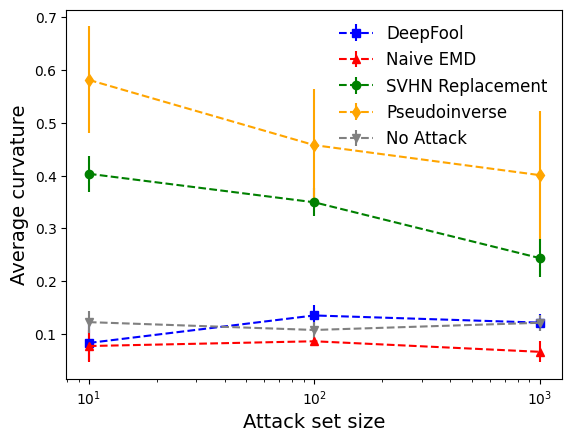

In [9]:
plot_prefix(f'{cifar_dir}/deepfool02_mobile', fmt='s--', label='DeepFool', color='blue')
plot_prefix(f'{cifar_dir}/naiveemd_mobile', fmt='^--', label='Naive EMD', color='red')
plot_prefix(f'{cifar_dir}/svhn_mobile', fmt='o--', label='SVHN Replacement', color='green')
plot_prefix(f'{cifar_dir}/pinv_mobile', fmt='d--', label='Pseudoinverse', color='orange')
plot_non(f'{cifar_dir}/pinv_mobile', fmt='v--', label='No Attack', color='grey')
plt.xscale('log')
plt.ylabel('Average curvature', fontsize=14)
plt.xlabel('Attack set size', fontsize=14)
plt.legend(loc='upper right', frameon=False, fontsize=12)
plt.show()

In [10]:
svhn_dir = './svhn_curv_scores'

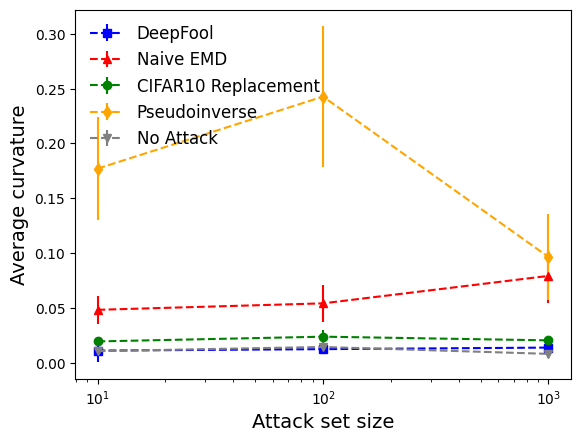

In [11]:
plot_prefix(f'{svhn_dir}/deepfool02_vgg', fmt='s--', label='DeepFool', color='blue')
plot_prefix(f'{svhn_dir}/naiveemd_vgg', fmt='^--', label='Naive EMD', color='red')
plot_prefix(f'{svhn_dir}/cifar10_vgg', fmt='o--', label='CIFAR10 Replacement', color='green')
plot_prefix(f'{svhn_dir}/pinv_vgg', fmt='d--', label='Pseudoinverse', color='orange')
plot_non(f'{svhn_dir}/pinv_vgg', fmt='v--', label='No Attack', color='grey')
plt.xscale('log')
plt.ylabel('Average curvature', fontsize=14)
plt.xlabel('Attack set size', fontsize=14)
plt.legend(loc='upper left', frameon=False, fontsize=12)
plt.show()

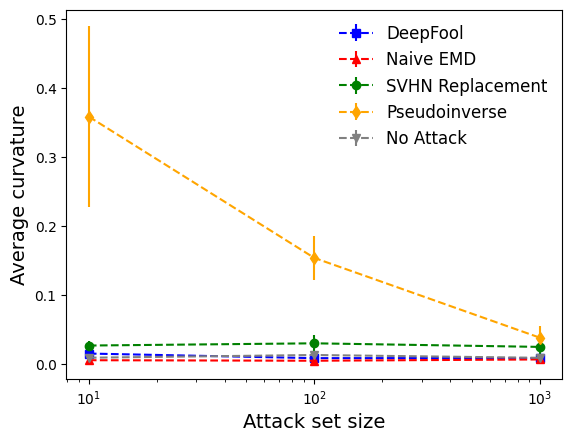

In [12]:
plot_prefix(f'{svhn_dir}/deepfool02_resnet', fmt='s--', label='DeepFool', color='blue')
plot_prefix(f'{svhn_dir}/naiveemd_resnet', fmt='^--', label='Naive EMD', color='red')
plot_prefix(f'{svhn_dir}/cifar10_resnet', fmt='o--', label='SVHN Replacement', color='green')
plot_prefix(f'{svhn_dir}/pinv_resnet', fmt='d--', label='Pseudoinverse', color='orange')
plot_non(f'{svhn_dir}/pinv_resnet', fmt='v--', label='No Attack', color='grey')
plt.xscale('log')
plt.ylabel('Average curvature', fontsize=14)
plt.xlabel('Attack set size', fontsize=14)
plt.legend(loc='upper right', frameon=False, fontsize=12)
plt.show()

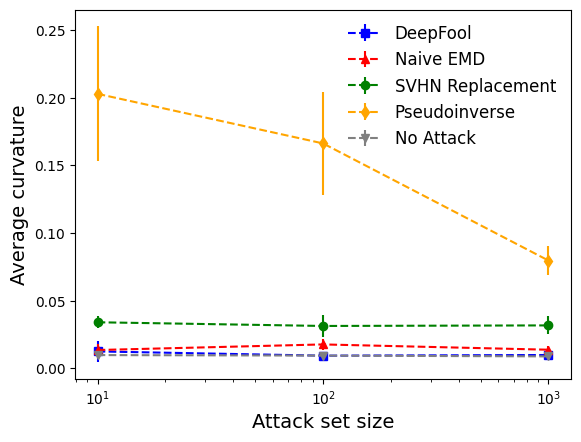

In [13]:
plot_prefix(f'{svhn_dir}/deepfool02_mobile', fmt='s--', label='DeepFool', color='blue')
plot_prefix(f'{svhn_dir}/naiveemd_mobile', fmt='^--', label='Naive EMD', color='red')
plot_prefix(f'{svhn_dir}/cifar10_mobile', fmt='o--', label='SVHN Replacement', color='green')
plot_prefix(f'{svhn_dir}/pinv_mobile', fmt='d--', label='Pseudoinverse', color='orange')
plot_non(f'{svhn_dir}/pinv_mobile', fmt='v--', label='No Attack', color='grey')
plt.xscale('log')
plt.ylabel('Average curvature', fontsize=14)
plt.xlabel('Attack set size', fontsize=14)
plt.legend(loc='upper right', frameon=False, fontsize=12)
plt.show()

In [14]:
mnist_dir = './mnist_curv_scores'

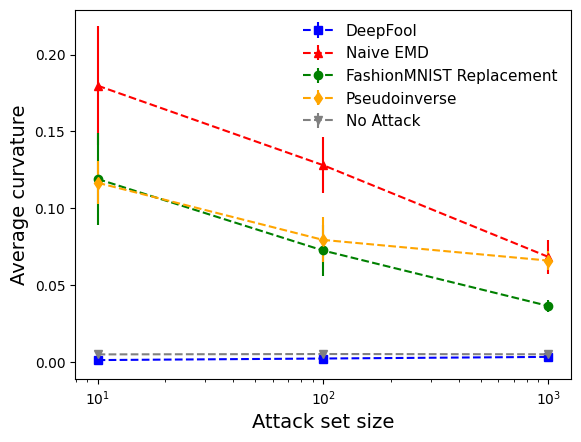

In [15]:
plot_prefix(f'{mnist_dir}/deepfool02_vgg', fmt='s--', label='DeepFool', color='blue')
plot_prefix(f'{mnist_dir}/naiveemd_vgg', fmt='^--', label='Naive EMD', color='red')
plot_prefix(f'{mnist_dir}/fashion_vgg', fmt='o--', label='FashionMNIST Replacement', color='green')
plot_prefix(f'{mnist_dir}/pinv_vgg', fmt='d--', label='Pseudoinverse', color='orange')
plot_non(f'{mnist_dir}/pinv_vgg', fmt='v--', label='No Attack', color='grey')
plt.xscale('log')
plt.ylabel('Average curvature', fontsize=14)
plt.xlabel('Attack set size', fontsize=14)
plt.legend(loc='upper right', frameon=False, fontsize=11)
plt.show()

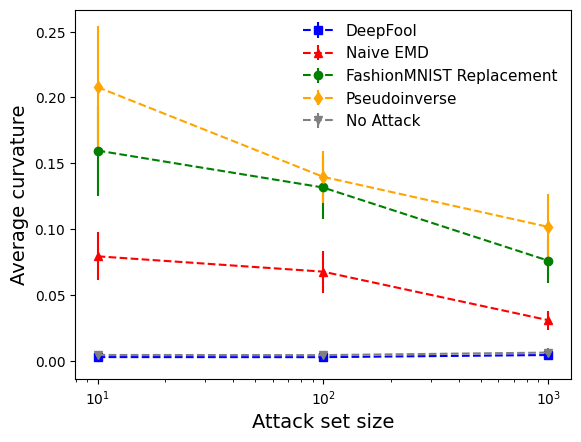

In [16]:
plot_prefix(f'{mnist_dir}/deepfool02_resnet', fmt='s--', label='DeepFool', color='blue')
plot_prefix(f'{mnist_dir}/naiveemd_resnet', fmt='^--', label='Naive EMD', color='red')
plot_prefix(f'{mnist_dir}/fashion_resnet', fmt='o--', label='FashionMNIST Replacement', color='green')
plot_prefix(f'{mnist_dir}/pinv_resnet', fmt='d--', label='Pseudoinverse', color='orange')
plot_non(f'{mnist_dir}/pinv_resnet', fmt='v--', label='No Attack', color='grey')
plt.xscale('log')
plt.ylabel('Average curvature', fontsize=14)
plt.xlabel('Attack set size', fontsize=14)
plt.legend(loc='upper right', frameon=False, fontsize=11)
plt.show()

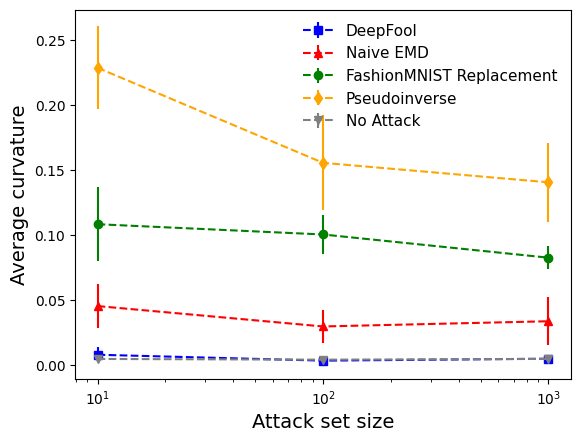

In [17]:
plot_prefix(f'{mnist_dir}/deepfool02_mobile', fmt='s--', label='DeepFool', color='blue')
plot_prefix(f'{mnist_dir}/naiveemd_mobile', fmt='^--', label='Naive EMD', color='red')
plot_prefix(f'{mnist_dir}/fashion_mobile', fmt='o--', label='FashionMNIST Replacement', color='green')
plot_prefix(f'{mnist_dir}/pinv_mobile', fmt='d--', label='Pseudoinverse', color='orange')
plot_non(f'{mnist_dir}/pinv_mobile', fmt='v--', label='No Attack', color='grey')
plt.xscale('log')
plt.ylabel('Average curvature', fontsize=14)
plt.xlabel('Attack set size', fontsize=14)
plt.legend(loc='upper right', frameon=False, fontsize=11)
plt.show()